In [1]:
!pip install pytorch-tabnet --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# MLP model
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc

# TabNet model
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [3]:

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/nomwesigwakeith/eyetrack/eye_tracking_data.csv', sep=';')

# Encode categorical columns into numeric values
le = LabelEncoder()
for col in ['Gender', 'Nativelang', 'Otherlang', 'Dyslexia']:
    df[col] = le.fit_transform(df[col])

# Separate features from the target column
X = df.drop('Dyslexia', axis=1)
y = df['Dyslexia']

# Scale features to have mean 0 and standard deviation 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:

# Build the MLP
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                    solver='adam', max_iter=500, random_state=42)

# Train on the 80%
mlp.fit(X_train, y_train)

# Generate predictions and probability scores on the test set
y_pred_mlp  = mlp.predict(X_test)
y_proba_mlp = mlp.predict_proba(X_test)[:, 1]

# Evaluate performance across all key metrics
print("MLP Test Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall   :", recall_score(y_test, y_pred_mlp))
print("F1 Score :", f1_score(y_test, y_pred_mlp))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_mlp))

MLP Test Performance
Accuracy : 0.8984910836762688
Precision: 0.5384615384615384
Recall   : 0.358974358974359
F1 Score : 0.4307692307692308
ROC-AUC  : 0.8127535546890385


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Build TabNet with sequential attention steps
tabnet = TabNetClassifier(seed=42, verbose=0, device_name=device)

# Train on the 80%
tabnet.fit(
    X_train, y_train.values,
    eval_set=[(X_test, y_test.values)],
    eval_metric=['auc'],
    max_epochs=100,
    patience=20,
    batch_size=256
)

# Generate predictions and probability scores on the test set
y_pred_tabnet  = tabnet.predict(X_test)
y_proba_tabnet = tabnet.predict_proba(X_test)[:, 1]

# Evaluate performance across all key metrics
print("TabNet Test Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_tabnet))
print("Precision:", precision_score(y_test, y_pred_tabnet))
print("Recall   :", recall_score(y_test, y_pred_tabnet))
print("F1 Score :", f1_score(y_test, y_pred_tabnet))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_tabnet))


Early stopping occurred at epoch 79 with best_epoch = 59 and best_val_0_auc = 0.84017


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Test Performance
Accuracy : 0.8930041152263375
Precision: 0.5
Recall   : 0.5256410256410257
F1 Score : 0.5125
ROC-AUC  : 0.840167001457324


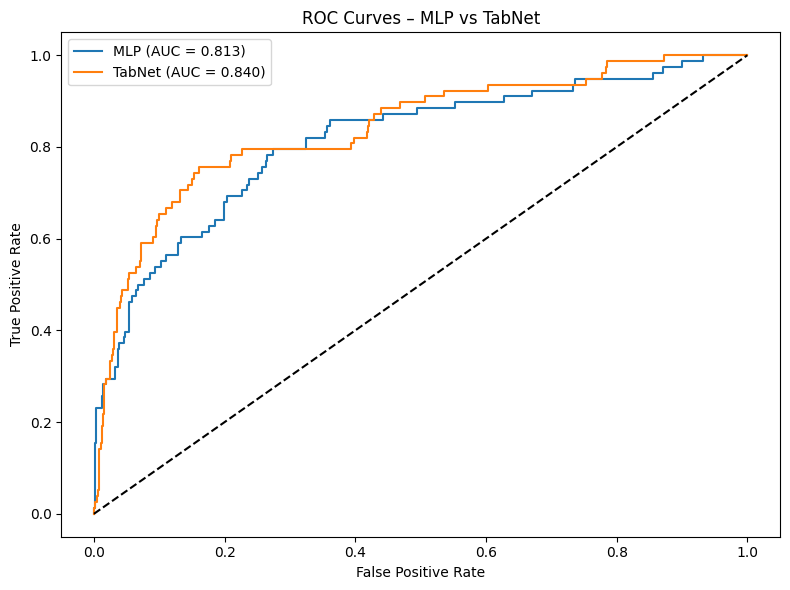

In [6]:
# Compute ROC curve points for each model
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
fpr_tab, tpr_tab, _ = roc_curve(y_test, y_proba_tabnet)

# Plot both curves on the same figure for direct comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot(fpr_tab, tpr_tab, label=f'TabNet (AUC = {auc(fpr_tab, tpr_tab):.3f})')

# Diagonal line represents a random classifier — both models should be well above
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – MLP vs TabNet')
plt.legend()
plt.tight_layout()
plt.show()

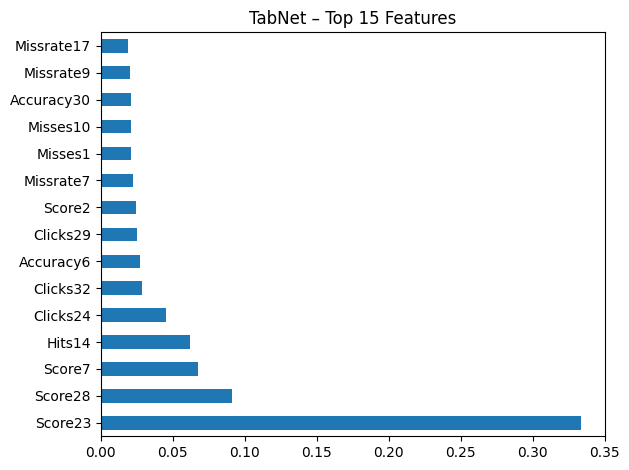

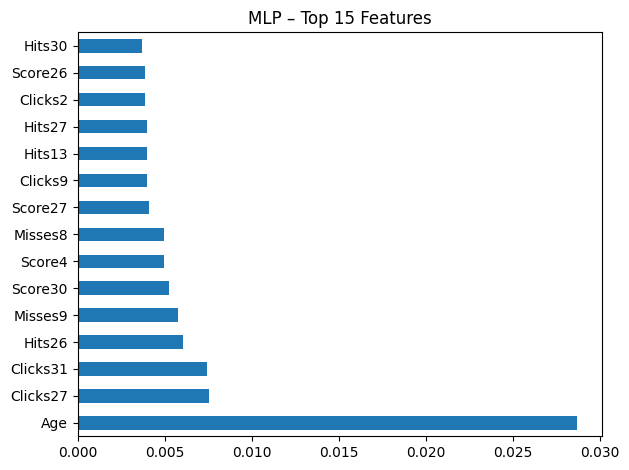

In [7]:
# TabNet has built-in feature importance derived from its attention masks
feat_imp_tabnet = pd.Series(tabnet.feature_importances_, index=X.columns)
feat_imp_tabnet.sort_values(ascending=False).head(15).plot(
    kind='barh', title='TabNet – Top 15 Features'
)
plt.tight_layout()
plt.show()

# MLP has no built-in importance so we use permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)
feat_imp_mlp = pd.Series(result.importances_mean, index=X.columns)
feat_imp_mlp.sort_values(ascending=False).head(15).plot(
    kind='barh', title='MLP – Top 15 Features'
)
plt.tight_layout()
plt.show()

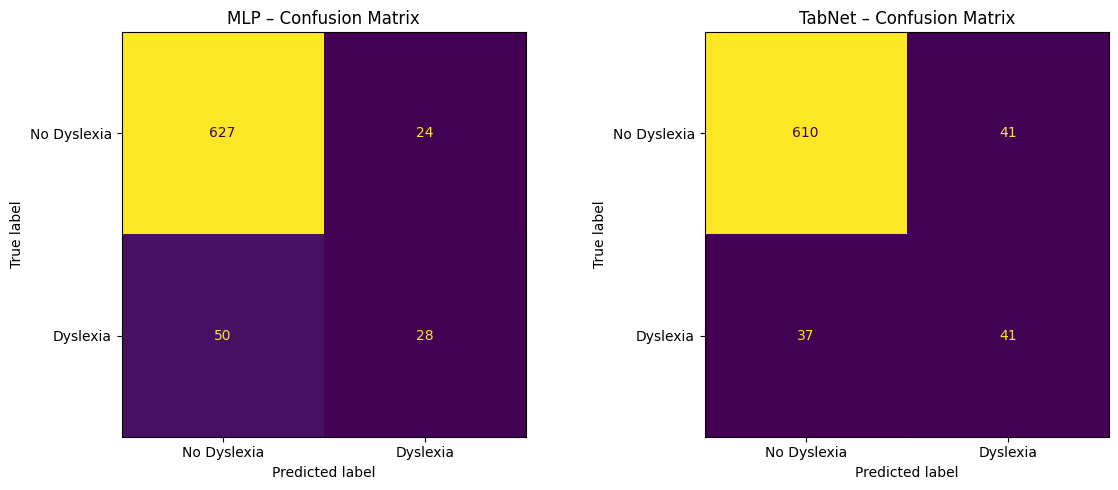

In [8]:
# Plot confusion matrices side by side for both models
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=['No Dyslexia', 'Dyslexia'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('MLP – Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tabnet,
    display_labels=['No Dyslexia', 'Dyslexia'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('TabNet – Confusion Matrix')

plt.tight_layout()
plt.show()

In [9]:
import pickle

# Save MLP
with open('/kaggle/working/mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)

# Save scaler
with open('/kaggle/working/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save TabNet
tabnet.save_model('/kaggle/working/tabnet_model')

print("All models saved")

Successfully saved model at /kaggle/working/tabnet_model.zip
All models saved
